# Vector Embeddings & Semantic Similarity Demo

This notebook has been created to demonstrate how sentence embeddings capture the semantic meaning using the `all-MiniLM-L6-v2` model from sentence-transformers.
10 sentences defined across 3 topics (Cricket, Cooking, Cybersecurity), embeddings generated, similarity visualized, and a semantic search query has been performed.

In [7]:
!pip install -q sentence-transformers

In [8]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

## Step 1: Define 10 Sentences Across 3 Topics

In [9]:
sentences = [
    # Cricket (4 sentences)
    "The batsman scored a brilliant century in the fourth innings of the test match.",
    "India won the Cricket World Cup after a nail-biting final against Australia.",
    "The spin bowler delivered a perfect googly to dismiss the opening batsman.",
    "The fielder took a stunning catch running in from the boundary to turn the match around.",
    # Cooking (3 sentences)
    "Marinate the chicken with yogurt and spices for at least two hours before grilling.",
    "A slow-cooked biryani with saffron and caramelized onions is a classic Indian dish.",
    "Knead the dough thoroughly and let it rest before rolling out fresh chapatis.",
    # Cybersecurity (3 sentences)
    "A phishing attack tricks users into revealing sensitive credentials through fake emails.",
    "Implementing multi-factor authentication significantly reduces the risk of unauthorized access.",
    "The security team detected a ransomware intrusion and isolated the affected servers immediately."
]

labels = [
    "Cricket-1", "Cricket-2", "Cricket-3", "Cricket-4",
    "Cooking-1", "Cooking-2", "Cooking-3",
    "CyberSec-1", "CyberSec-2", "CyberSec-3"
]

for label, sentence in zip(labels, sentences):
    print(f"{label}: {sentence}")

Cricket-1: The batsman scored a brilliant century in the fourth innings of the test match.
Cricket-2: India won the Cricket World Cup after a nail-biting final against Australia.
Cricket-3: The spin bowler delivered a perfect googly to dismiss the opening batsman.
Cricket-4: The fielder took a stunning catch running in from the boundary to turn the match around.
Cooking-1: Marinate the chicken with yogurt and spices for at least two hours before grilling.
Cooking-2: A slow-cooked biryani with saffron and caramelized onions is a classic Indian dish.
Cooking-3: Knead the dough thoroughly and let it rest before rolling out fresh chapatis.
CyberSec-1: A phishing attack tricks users into revealing sensitive credentials through fake emails.
CyberSec-2: Implementing multi-factor authentication significantly reduces the risk of unauthorized access.
CyberSec-3: The security team detected a ransomware intrusion and isolated the affected servers immediately.


## Step 2: Generate Embeddings Using all-MiniLM-L6-v2

In [10]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print(f"Number of sentences: {len(embeddings)}")
print(f"Embedding dimension: {embeddings.shape[1]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of sentences: 10
Embedding dimension: 384


## Step 3: Compute and Display 10x10 Cosine Similarity Heatmap

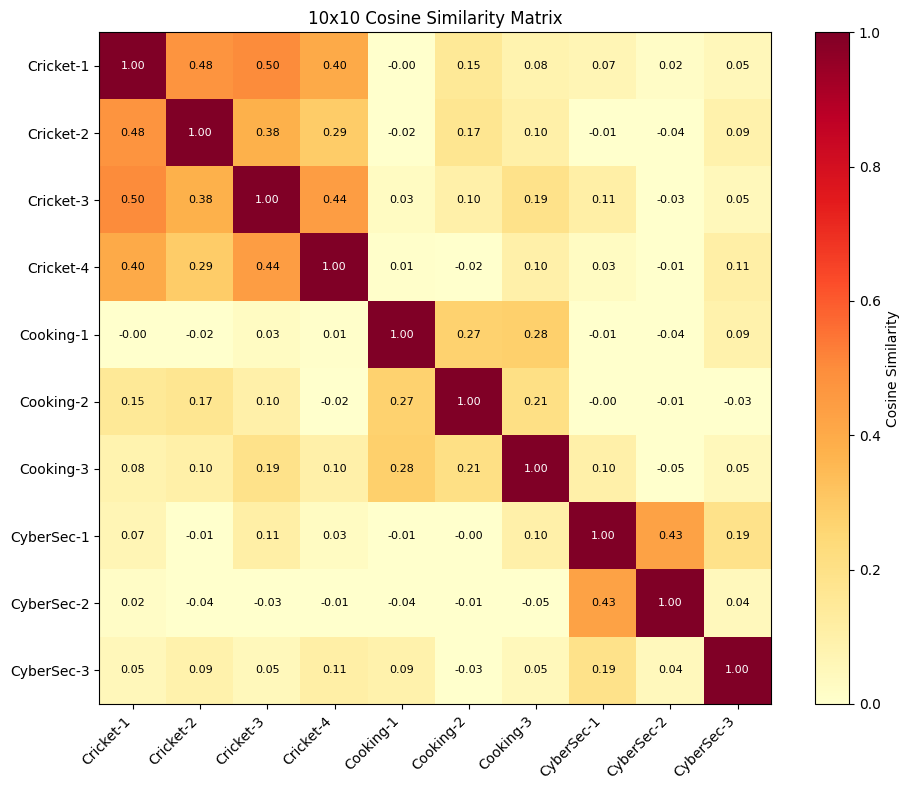

In [11]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix, cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)
plt.title('10x10 Cosine Similarity Matrix')

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, f'{similarity_matrix[i][j]:.2f}',
                 ha='center', va='center', fontsize=8,
                 color='white' if similarity_matrix[i][j] > 0.6 else 'black')

plt.tight_layout()
plt.show()

## Step 4: Semantic Search â€” Find Top 2 Most Similar Sentences to a Query

In [12]:
query = "The pacer took three wickets in a single over"
query_embedding = model.encode([query])

query_similarities = cosine_similarity(query_embedding, embeddings)[0]

top_2_indices = np.argsort(query_similarities)[-2:][::-1]

print(f"Query: \"{query}\"\n")
print("Top 2 Most Similar Sentences:")
print("=" * 60)
for rank, idx in enumerate(top_2_indices, 1):
    print(f"\n#{rank} [{labels[idx]}] (Similarity: {query_similarities[idx]:.4f})")
    print(f"   \"{sentences[idx]}\"")

Query: "The pacer took three wickets in a single over"

Top 2 Most Similar Sentences:

#1 [Cricket-1] (Similarity: 0.5023)
   "The batsman scored a brilliant century in the fourth innings of the test match."

#2 [Cricket-4] (Similarity: 0.4138)
   "The fielder took a stunning catch running in from the boundary to turn the match around."
